In [1]:
import pandas as pd
import numpy as np
import re
from urllib.parse import urlparse
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from bs4 import BeautifulSoup
import requests
import time
import matplotlib.pyplot as plt
from tensorflow.keras.layers import BatchNormalization
from keras.regularizers import l2
from tensorflow.keras.utils import plot_model
from keras.callbacks import ReduceLROnPlateau
import os 

In [2]:

start_time = time.time()
# 新的特徵提取函數
def extract_features(url):
    try:
        print(f"Processing URL: {url}")  
        parsed_url = urlparse(url)
        hostname = parsed_url.netloc
        path = parsed_url.path
        query = parsed_url.query
        tld = hostname.split('.')[-1] if '.' in hostname else ''
        features = {
            'url_length': len(url),
            'domain_length': len(parsed_url.netloc),
            'tld': parsed_url.netloc.split('.')[-1] if '.' in parsed_url.netloc else '',
            'has_ip': int(parsed_url.netloc.replace('.', '').isdigit()),  # 判斷是否有 IP 地址
            'num_special_chars': sum(not c.isalnum() and c not in ['.', ':', '/'] for c in url),
            'has_https': int(parsed_url.scheme == 'https'),
            'has_www': int('www.' in parsed_url.netloc),
            'pct_ext_hyperlinks': 0.0,
            'pct_ext_resource_urls': 0.0,
            'ext_favicon': 0.0,
            'num_dots': hostname.count('.'),
            'subdomain_level': hostname.count('.') - 1,
            'path_level': path.count('/'),
            'num_dash': url.count('-'),
            'num_dash_in_hostname': hostname.count('-'),
            'at_symbol': int('@' in url),
            'tilde_symbol': int('~' in url),
            'num_underscore': url.count('_'),
            'num_percent': url.count('%'),
            'num_query_components': query.count('&') + 1 if query else 0,
            'num_ampersand': url.count('&'),
            'num_hash': url.count('#'),
            'num_numeric_chars': sum(c.isdigit() for c in url),
            'no_https': int(parsed_url.scheme != 'https'),
            'random_string': int(bool(re.search(r'\b[a-zA-Z]{10,}\b', hostname))),
            'ip_address': int(bool(re.match(r'\b\d{1,3}(\.\d{1,3}){3}\b', hostname))),
            'domain_in_subdomains': int(any(tld in hostname for tld in ['com', 'org', 'net', 'edu', 'gov'])),
            'domain_in_paths': int(any(tld in path for tld in ['com', 'org', 'net', 'edu', 'gov'])),
            'https_in_hostname': int('https' in hostname),
            'hostname_length': len(hostname),
            'path_length': len(path),
            'query_length': len(query),
            'double_slash_in_path': int('//' in path),
            'num_sensitive_words': sum(word in url for word in ['secure', 'account', 'update', 'login']),
            'embedded_brand_name': int(any(brand in hostname for brand in ['facebook', 'google', 'paypal'])),
            'insecure_forms': 0,
            'relative_form_action': 0,
            'ext_form_action': 0,
            'abnormal_form_action': 0,
            # 'feedback':5.0
        }

        try:
            response = requests.get(url, timeout=5)
            if response.status_code == 200:
                soup = BeautifulSoup(response.content, 'html.parser')
                features.update({
                    'pct_ext_hyperlinks': len(soup.find_all('a', href=True)) / (len(soup.find_all('a')) + 1),
                    'pct_ext_resource_urls': len(soup.find_all(src=True)) / (len(soup.find_all()) + 1),
                    'ext_favicon': int(bool(soup.find('link', rel='icon', href=True))),
                    'insecure_forms': int(any(form['action'].startswith('http:') for form in soup.find_all('form', action=True))),
                    'relative_form_action': int(any(form['action'].startswith('/') for form in soup.find_all('form', action=True))),
                    'ext_form_action': int(any(not form['action'].startswith(url) for form in soup.find_all('form', action=True))),
                    'abnormal_form_action': int(any(form['action'] in ['#', 'about:blank', 'javascript:true'] for form in soup.find_all('form', action=True))),
                    # 更多 HTML 相關特徵可以在這裡添加
                })
        except requests.exceptions.RequestException:
            pass
        print(f"Finished processing URL: {url}\n{features}") 
        return features
    
    except Exception as e:
        print(f"Error processing URL {url}: {e}")
        return {}
# 特徵提取並建立特徵數據框
# features = data['url'].apply(lambda x: extract_features(str(x)))
# features_df = pd.DataFrame(features.tolist())
# features_df.to_csv('Phishing_Dataset4_features.csv', index=False, encoding='utf-8')

In [3]:
def model(data,features_df,rs,lr,ep):
    # print(features_df)
    # 處理 TLD 特徵（使用 One-Hot Encoding）
    features_df = pd.get_dummies(features_df, columns=['tld'])
    # 準備數據
    X = features_df
    y = data['label'].apply(lambda x: 1 if x == 'malicious' else 0)  # 轉換標籤為二元格式
    # 分割數據集
    # columns_to_remove = ['url']
    # X_train = X_train.drop(columns_to_remove, axis=1)
    # X_test = X_test.drop(columns_to_remove, axis=1)
    # print(X_train.dtypes)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=rs)
    # 標準化數據
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    from sklearn.impute import SimpleImputer

    # 使用 SimpleImputer 填充 NaN 值
    imputer = SimpleImputer(strategy='most_frequent')  # 或者使用 'median' 或 'most_frequent'
    X_train = imputer.fit_transform(X_train)
    X_test = imputer.transform(X_test)

    # 再次檢查 NaN 值
    # print("NaN values in X_train after imputation:", np.isnan(X_train).sum())
    # print("NaN values in X_test after imputation:", np.isnan(X_test).sum())

    # # 檢查無窮大值
    # print("Inf values in X_train:", np.isinf(X_train).sum())
    # print("Inf values in X_test:", np.isinf(X_test).sum())

    # 建立 MLP 模型
    model = Sequential()
    model.add(Dense(16, input_dim=X_train.shape[1], activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.4))
    model.add(Dense(8, activation='relu', kernel_regularizer=l2(0.04)))
    model.add(Dropout(0.5))  
    model.add(Dense(1, activation='sigmoid'))

    # 編譯模型
    # model.compile(optimizer=Adam(learning_rate=0.00005), loss='binary_crossentropy', metrics=['accuracy'])
    model.compile(optimizer=Adam(learning_rate=lr), loss='binary_crossentropy', metrics=['accuracy'])

    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5,verbose=1)
    # # 訓練模型
    history = model.fit(X_train, y_train, epochs=ep, batch_size=32, validation_split=0.2, callbacks=[reduce_lr],verbose=1)
    # from keras.callbacks import EarlyStopping

    # early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    # history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, callbacks=[reduce_lr, early_stopping], verbose=1)

    plot_model(model, to_file='mlp_model.png', show_shapes=True, show_layer_names=True)
    # 預測
    y_pred = (model.predict(X_test) > 0.5).astype(int).flatten()
    # 評估模型
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    plt.rcParams['font.family'] = 'Arial'
    # 繪製訓練與驗證的損失並保存圖片
    plt.plot(history.history['loss'], label='training_loss')
    plt.plot(history.history['val_loss'], label='test_loss')
    plt.title('LOSS')
    plt.xlabel('Epochs')
    plt.ylabel('loss')
    plt.legend()
    # plt.close()

    # 繪製訓練與驗證的準確率並保存圖片
    plt.plot(history.history['accuracy'], label='training_accuracy')
    plt.plot(history.history['val_accuracy'], label='test_accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('accuracy')
    plt.legend()
    # plt.close()

    return model,scaler,X

    # 查看權重
    # for layer in model.layers:
    #     weights = layer.get_weights()
    #     print(f"Layer: {layer.name}")
    #     for i, weight in enumerate(weights):
    #         print(f"  Weight {i}: shape {weight.shape}")
    #         print(f"  {weight}\n")

Epoch 1/20


/opt/homebrew/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1571/1571 ━━━━━━━━━━━━━━━━━━━━ 2s 616us/step - accuracy: 0.4972 - loss: 1.4205 - val_accuracy: 0.4515 - val_loss: 1.2222 - learning_rate: 3.0000e-06
Epoch 2/20
1571/1571 ━━━━━━━━━━━━━━━━━━━━ 1s 503us/step - accuracy: 0.5165 - loss: 1.3688 - val_accuracy: 0.4736 - val_loss: 1.2091 - learning_rate: 3.0000e-06
Epoch 3/20
1571/1571 ━━━━━━━━━━━━━━━━━━━━ 1s 499us/step - accuracy: 0.5306 - loss: 1.3387 - val_accuracy: 0.5436 - val_loss: 1.1566 - learning_rate: 3.0000e-06
Epoch 4/20
1571/1571 ━━━━━━━━━━━━━━━━━━━━ 1s 502us/step - accuracy: 0.5426 - loss: 1.3086 - val_accuracy: 0.6034 - val_loss: 1.1389 - learning_rate: 3.0000e-06
Epoch 5/20
1571/1571 ━━━━━━━━━━━━━━━━━━━━ 1s 547us/step - accuracy: 0.5583 - loss: 1.2734 - val_accuracy: 0.6268 - val_loss: 1.1274 - learning_rate: 3.0000e-06
Epoch 6/20
1571/1571 ━━━━━━━━━━━━━━━━━━━━ 1s 505us/step - accuracy: 0.5712 - loss: 1.2407 - val_accuracy: 0.6845 - val_loss: 1.1029 - learning_rate: 3.0000e-06
Epoch 7/20
1571/1571 ━━━━━━━━━━━━━━━━━━━━ 1s 536us/

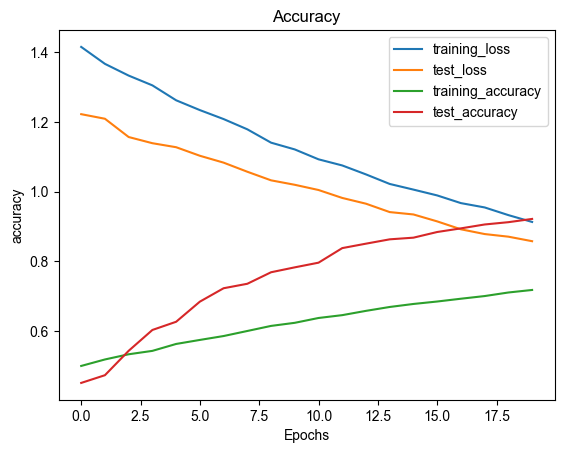

In [4]:
# 讀取數據
data = pd.read_csv('Phishing_Dataset.csv', encoding='utf-8')
features_df = pd.read_csv('Phishing_Dataset1_features.csv')

rs = 1337
lr = 0.000003
ep = 20
model,scaler,X = model(data,features_df,rs,lr,ep)

rs = 1337 lr = 0.000003 ep =30  
accuracy                           0.94     26920   
   macro avg       0.94      0.94      0.94     26920   
weighted avg       0.94      0.94      0.94     26920



In [5]:

def scale_prediction(prediction):

    return prediction * 10.0

# quit()
def predict_url(model, url, scaler):
    # 提取 URL 的特徵
    features = extract_features(url)
    features_df = pd.DataFrame([features])
    # features_df = features_df.drop(columns=['url'])
    # 移除不必要的欄位 'url'
    if 'url' in features_df.columns:
        features_df = features_df.drop(columns=['url'])
    # 對 'tld' 進行 one-hot 編碼
    features_df = pd.get_dummies(features_df, columns=['tld'])
    # 確保列名與訓練模型時的一致，缺失特徵填補為 0
    features_df = features_df.reindex(columns=X.columns, fill_value=0)
    # 進行標準化
    print(features_df)
    features_scaled = scaler.transform(features_df)
    # 預測結果
    raw_prediction = model.predict(features_scaled)[0][0]
    # 將預測結果進行縮放
    scaled_prediction = scale_prediction(raw_prediction)
    # 處理 NAN 的情況
    if np.isnan(scaled_prediction):
        scaled_prediction = 0.0

    return features, scaled_prediction
# 測試網址列表
true_website = []
phishing_website = []

with open("0_testwebsite", 'r', encoding='utf-8') as file:
    test_urls = file.read().split("\n")

# 過濾無效的 URL
urls_to_test = [url for url in test_urls if url and url not in ['True Website', 'Phishing Website', '']]

# 打印預測結果
results = []
for url in urls_to_test:
    features, prediction = predict_url(model, url, scaler)
    result = {
        'url': url,
        'prediction': 'malicious' if prediction < 5.0 else 'benign',  # 分數低於 5.0 的是釣魚網站
        'score': prediction  # 添加預測分數
    }
    result.update(features)  # 更新特徵信息
    results.append(result)
    # print(f"URL: {url}\nPrediction: {result['prediction']}\nScore: {result['score']}\nFeatures: {features}\n")

# 將結果存儲到 CSV
results_df = pd.DataFrame(results)
results_df.to_csv('Phishing_Dataset1_result1.csv', index=False, encoding='utf-8')

# 記錄時間
end_time = time.time()
print(end_time - start_time)

Processing URL: https://www.facebook.com/?locale=zh_TW
Finished processing URL: https://www.facebook.com/?locale=zh_TW
{'url_length': 38, 'domain_length': 16, 'tld': 'com', 'has_ip': 0, 'num_special_chars': 3, 'has_https': 1, 'has_www': 1, 'pct_ext_hyperlinks': 0.9795918367346939, 'pct_ext_resource_urls': 0.015789473684210527, 'ext_favicon': 1, 'num_dots': 2, 'subdomain_level': 1, 'path_level': 1, 'num_dash': 0, 'num_dash_in_hostname': 0, 'at_symbol': 0, 'tilde_symbol': 0, 'num_underscore': 1, 'num_percent': 0, 'num_query_components': 1, 'num_ampersand': 0, 'num_hash': 0, 'num_numeric_chars': 0, 'no_https': 0, 'random_string': 0, 'ip_address': 0, 'domain_in_subdomains': 1, 'domain_in_paths': 0, 'https_in_hostname': 0, 'hostname_length': 16, 'path_length': 1, 'query_length': 12, 'double_slash_in_path': 0, 'num_sensitive_words': 0, 'embedded_brand_name': 1, 'insecure_forms': 0, 'relative_form_action': 1, 'ext_form_action': 1, 'abnormal_form_action': 0}
   url_length  domain_length  has_i

In [31]:
def adjust_feedback(existing_feedback, adjustment):
    # 控制feedback的最大/最小值範圍，避免超出邊界
    max_feedback = 10.0
    min_feedback = 0.0
    
    # 根據當前feedback的距離邊界的程度進行調整
    if adjustment > 0:
        # 如果反饋是正向的，即用戶認為是安全網站
        new_feedback = min(existing_feedback + adjustment, max_feedback)
    else:
        # 如果反饋是負向的，即用戶認為是釣魚網站
        new_feedback = max(existing_feedback + adjustment, min_feedback)

    return new_feedback

In [32]:
def predict_url_2(model, url, scaler):
    try:
        results_df = pd.read_csv('Phishing_Dataset1_result2.csv')
        url_in_csv = url in results_df['url'].values
        if url_in_csv:
            print("URL已存在，根據現有預測結果。")
            existing_result = results_df.loc[results_df['url'] == url].iloc[0].to_dict()
            print(f"當前預測：{existing_result['prediction']}, 分數：{existing_result['score']}")
            # 使用者提供反饋
            input_feedback = input("這是釣魚網站嗎？(Yes = 1, No = 2, Nothing = 3): ")
            if input_feedback.isdigit():
                input_feedback = int(input_feedback)
                if input_feedback == 1:
                    # 用戶反饋為釣魚網站，減少 feedback 權重
                    new_feedback = adjust_feedback(existing_result['feedback'], -0.5)
                    results_df.loc[results_df['url'] == url, 'feedback'] = new_feedback
                elif input_feedback == 2:
                    # 用戶反饋為安全網站，增加 feedback 權重
                    new_feedback = adjust_feedback(existing_result['feedback'], 0.5)
                    results_df.loc[results_df['url'] == url, 'feedback'] = new_feedback
                else:
                    new_feedback = adjust_feedback(existing_result['feedback'], 0.0)
                    results_df.loc[results_df['url'] == url, 'feedback'] = new_feedback

                # 使用更新的 feedback 欄位重新進行預測
                features = extract_features(url)
                features_df = pd.DataFrame([features])
                features_df = pd.get_dummies(features_df, columns=['tld'])
                features_df = features_df.reindex(columns=X.columns, fill_value=0)
                features_scaled = scaler.transform(features_df)
                raw_prediction = model.predict(features_scaled)[0][0]
                scaled_prediction = scale_prediction(raw_prediction)
                final_score = scaled_prediction * 0.5 + new_feedback * 0.5

                if np.isnan(scaled_prediction):
                    scaled_prediction = 0.0

                # 更新新的預測結果
                results_df.loc[results_df['url'] == url, 'score'] = final_score
                results_df.loc[results_df['url'] == url, 'prediction'] = 'malicious' if final_score < 5.0 else 'benign'

            result = results_df.loc[results_df['url'] == url].iloc[0].to_dict()
        else:
            raise FileNotFoundError
    except FileNotFoundError:
        print("結果文件不存在，創建新文件...")
        features = extract_features(url)
        features_df = pd.DataFrame([features])
        features_df = pd.get_dummies(features_df, columns=['tld'])
        features_df = features_df.reindex(columns=X.columns, fill_value=0)
        features_scaled = scaler.transform(features_df)
        raw_prediction = model.predict(features_scaled)[0][0]
        scaled_prediction = scale_prediction(raw_prediction)
        if np.isnan(scaled_prediction):
            scaled_prediction = 0.0
        feedback = 5.0
        final_score = scaled_prediction * 0.7 + feedback * 0.3
        result = {
            'url': url,
            'prediction': 'malicious' if final_score < 5.0 else 'benign',
            'score': final_score,
            'feedback': feedback
        }
        result.update(features)
        result.update({'feedback': feedback})
        new_result_df = pd.DataFrame([result])
        if 'results_df' in locals():
            results_df = pd.concat([results_df, new_result_df], ignore_index=True)
        else:
            results_df = new_result_df

    # 最後寫入 CSV
    results_df.to_csv('Phishing_Dataset1_result2.csv', index=False, encoding='utf-8')

    return features, scaled_prediction, result

In [ ]:
while(1):
    input_url = input("Input your url(input exit to quit): ")
    if input_url == "exit":
        break
    features, prediction,result = predict_url_2(model, input_url, scaler)
    # print(f"URL: {result['url']}\nPrediction: {result['prediction']}\nScore: {result['score']}\nFeatures: {result}\n")

結果文件不存在，創建新文件...
Processing URL: https://drive.google.com/drive/my-drive
Finished processing URL: https://drive.google.com/drive/my-drive
{'url_length': 39, 'domain_length': 16, 'tld': 'com', 'has_ip': 0, 'num_special_chars': 1, 'has_https': 1, 'has_www': 0, 'pct_ext_hyperlinks': 0.8571428571428571, 'pct_ext_resource_urls': 0.005714285714285714, 'ext_favicon': 0, 'num_dots': 2, 'subdomain_level': 1, 'path_level': 2, 'num_dash': 1, 'num_dash_in_hostname': 0, 'at_symbol': 0, 'tilde_symbol': 0, 'num_underscore': 0, 'num_percent': 0, 'num_query_components': 0, 'num_ampersand': 0, 'num_hash': 0, 'num_numeric_chars': 0, 'no_https': 0, 'random_string': 0, 'ip_address': 0, 'domain_in_subdomains': 1, 'domain_in_paths': 0, 'https_in_hostname': 0, 'hostname_length': 16, 'path_length': 15, 'query_length': 0, 'double_slash_in_path': 0, 'num_sensitive_words': 0, 'embedded_brand_name': 1, 'insecure_forms': 0, 'relative_form_action': 1, 'ext_form_action': 1, 'abnormal_form_action': 0}
1/1 ━━━━━━━━━━━━